Dataset size after cleaning: 1128
Number of molecules: 1128
Number of descriptors: 4

Descriptors used:
['MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors']

Training samples: 902
Testing samples: 226

Starting hyperparameter optimization...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best hyperparameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Model Performance on Test Set
----------------------------------------
MAE  : 0.5949
MSE  : 0.7415
RMSE : 0.8611
R²   : 0.8431


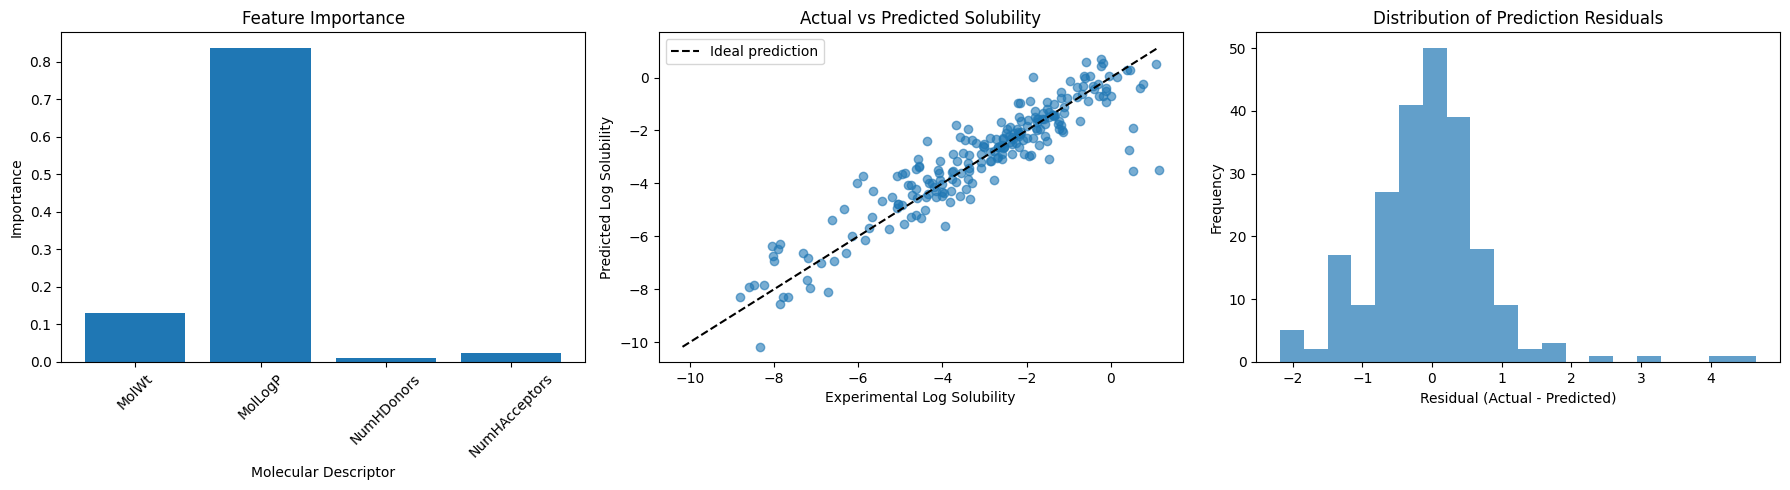

In [4]:
# Solubility Prediction Using Random Forest

## 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# ---------------------------------------------------------
# 2. Molecular Descriptor Calculation
# ---------------------------------------------------------

def compute_descriptors(smiles):
    """
    Calculate selected molecular descriptors from a SMILES string.

    Descriptors:
    - Molecular Weight
    - MolLogP
    - Number of Hydrogen Bond Donors
    - Number of Hydrogen Bond Acceptors
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol)
    }


# ---------------------------------------------------------
# 3. Load and Clean Dataset
# ---------------------------------------------------------

data = pd.read_csv('delaney-processed.csv')

# Remove duplicate rows and rows with missing values
data = data.drop_duplicates().dropna()

print(f"Dataset size after cleaning: {len(data)}")


# ---------------------------------------------------------
# 4. Calculate Molecular Descriptors
# ---------------------------------------------------------

descriptor_data = data["smiles"].apply(compute_descriptors)

# Keep only molecules for which descriptors were successfully calculated
valid_mask = descriptor_data.notna()

features = pd.DataFrame(
    descriptor_data[valid_mask].tolist()
)

target = data.loc[
    valid_mask,
    "measured log solubility in mols per litre"
].reset_index(drop=True)

X = features.reset_index(drop=True)
y = target

print(f"Number of molecules: {len(X)}")
print(f"Number of descriptors: {X.shape[1]}")
print("\nDescriptors used:")
print(list(X.columns))


# ---------------------------------------------------------
# 5. Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


# ---------------------------------------------------------
# 6. Hyperparameter Grid
# ---------------------------------------------------------

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}


# ---------------------------------------------------------
# 7. Grid Search with 5-Fold Cross-Validation
# ---------------------------------------------------------

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

print("\nStarting hyperparameter optimization...")

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("\nBest hyperparameters:")
print(grid_search.best_params_)


# ---------------------------------------------------------
# 8. Test Set Prediction
# ---------------------------------------------------------

y_pred = best_model.predict(X_test)


# ---------------------------------------------------------
# 9. Model Evaluation
# ---------------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance on Test Set")
print("-" * 40)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# ---------------------------------------------------------
# 10. Visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Feature Importance
axes[0].bar(
    X.columns,
    best_model.feature_importances_
)

axes[0].set_title("Feature Importance")
axes[0].set_xlabel("Molecular Descriptor")
axes[0].set_ylabel("Importance")
axes[0].tick_params(axis="x", rotation=45)


# Actual vs Predicted
axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

axes[1].plot(
    [min_value, max_value],
    [min_value, max_value],
    "k--",
    label="Ideal prediction"
)

axes[1].set_title("Actual vs Predicted Solubility")
axes[1].set_xlabel("Experimental Log Solubility")
axes[1].set_ylabel("Predicted Log Solubility")
axes[1].legend()


# Residual Distribution
residuals = y_test - y_pred

axes[2].hist(
    residuals,
    bins=20,
    alpha=0.7
)

axes[2].set_title("Distribution of Prediction Residuals")
axes[2].set_xlabel("Residual (Actual - Predicted)")
axes[2].set_ylabel("Frequency")


plt.tight_layout()

plt.savefig(
    "solubility_prediction_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
